<a href="https://colab.research.google.com/github/deen-abdullah/Deep-Learning-for-Natural-Language-Processing/blob/main/Bengali_Speech_to_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bengali Speech-to-Text Prototype using a Fine-Tuned Wav2Vec2 Model

This notebook demonstrates a Bangla/Bengali speech-to-text prototype using a pretrained model fine-tuned for Bengali automatic speech recognition (ASR).

## Step 1: Install Required Libraries

In [2]:
!pip -q uninstall -y gradio gradio_client
!pip -q install "transformers==4.44.2" "huggingface-hub==0.36.2" accelerate librosa soundfile jiwer

## Step 2: Import Libraries

In [3]:
import os
import torch
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from google.colab import files
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from jiwer import wer, cer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## Step 3: Upload a Bangla Audio File

In [4]:
uploaded = files.upload()
audio_path = list(uploaded.keys())[0]
print("Uploaded audio file:", audio_path)


Saving bangla 001.m4a to bangla 001.m4a
Uploaded audio file: bangla 001.m4a


## Step 4: Listen to the Uploaded Audio

In [5]:
display(Audio(audio_path))


## Step 5: Load Audio as a 16 kHz Waveform

**Note:** Load the audio and resample it to `16,000 Hz`, because this Bengali Wav2Vec2 model expects 16 kHz audio (16,000 samples per second).


Example waveform idea:

```python
[0.0012, 0.0034, -0.0021, 0.0009, ...]
```

At this point, the data is still only sound, not text.


In [6]:
TARGET_SAMPLING_RATE = 16000

audio, sampling_rate = librosa.load(audio_path, sr=TARGET_SAMPLING_RATE, mono=True)
duration_seconds = len(audio) / sampling_rate

print("Waveform type:", type(audio))
print("Waveform shape:", audio.shape)
print("Sampling rate:", sampling_rate)
print("Duration in seconds:", round(duration_seconds, 2))
print("First 10 waveform values:")
print(audio[:10])


/tmp/ipykernel_5294/2270250650.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sampling_rate = librosa.load(audio_path, sr=TARGET_SAMPLING_RATE, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Waveform type: <class 'numpy.ndarray'>
Waveform shape: (30038,)
Sampling rate: 16000
Duration in seconds: 1.88
First 10 waveform values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Step 6: Visualize the Waveform

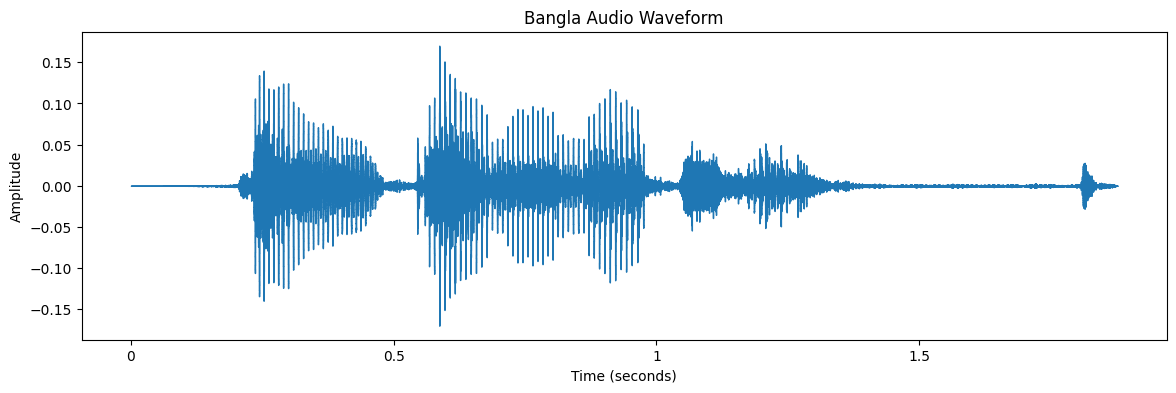

In [7]:
plt.figure(figsize=(14, 4))
librosa.display.waveshow(audio, sr=sampling_rate)
plt.title("Bangla Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


## Step 7: Load the Bengali Fine-Tuned Wav2Vec2 ASR Model
We use:

```python
arijitx/wav2vec2-xls-r-300m-bengali
```

This model is a fine-tuned version of facebook/wav2vec2-xls-r-300m on the OPENSLR_SLR53 - bengali dataset. https://huggingface.co/arijitx/wav2vec2-xls-r-300m-bengali


In [8]:
MODEL_NAME = "arijitx/wav2vec2-xls-r-300m-bengali"

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model = Wav2Vec2ForCTC.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

print("Loaded Bengali ASR model:", MODEL_NAME)
print("Model device:", next(model.parameters()).device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Some weights of the model checkpoint at arijitx/wav2vec2-xls-r-300m-bengali were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at arijitx/wav2vec2-xls-r-300m-bengali and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably T

Loaded Bengali ASR model: arijitx/wav2vec2-xls-r-300m-bengali
Model device: cuda:0


## Step 8: Convert Waveform into Model Input Values

In [9]:
inputs = processor(
    audio,
    sampling_rate=sampling_rate,
    return_tensors="pt",
    padding=True
)

input_values = inputs.input_values.to(DEVICE)

print("Input values type:", type(input_values))
print("Input values shape:", input_values.shape)
print("First 10 input values:")
print(input_values[0, :10].detach().cpu())


Input values type: <class 'torch.Tensor'>
Input values shape: torch.Size([1, 30038])
First 10 input values:
tensor([0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008,
        0.0008])


## Step 9: Internal Acoustic Feature Extraction

This is the key feature extraction stage inside Wav2Vec2.

**Input:** The prepared audio waveform tensor.  
**Processing:** Wav2Vec2 uses convolutional layers to convert the raw waveform into higher-level acoustic features. These features represent sound patterns over time. They are not words yet.

**Output:** `extract_features`, a numerical feature representation created by the model.

Presentation explanation:

> The model first transforms the raw sound signal into acoustic features. These features capture speech patterns such as changes in sound, frequency-like behavior, and temporal structure. The model has not produced Bangla text yet; it has only converted sound into learned numerical features.


In [10]:
with torch.no_grad():
    extract_features = model.wav2vec2.feature_extractor(input_values)

print("Extracted acoustic features shape:", extract_features.shape)
print("Small slice of acoustic features:")
print(extract_features[0, :5, :5].detach().cpu())


Extracted acoustic features shape: torch.Size([1, 512, 93])
Small slice of acoustic features:
tensor([[-0.1096, -0.1096, -0.1096, -0.1096, -0.0871],
        [-0.0447, -0.0447, -0.0447, -0.0447, -0.0375],
        [-0.1652, -0.1652, -0.1652, -0.1652, -0.1700],
        [-0.0455, -0.0455, -0.0455, -0.0455, -0.0409],
        [-0.0949, -0.0949, -0.0949, -0.0949, -0.0921]])


## Step 10: Full Model Forward Pass - Produce CTC Logits

**Input:** `input_values`.  
**Processing:** The full model processes the audio and produces `logits`. Logits are scores for every possible output token at each time step.

**Output:** `logits`, a 3D tensor:

```text
[batch_size, time_steps, vocabulary_size]
```

Meaning:

| Dimension | Meaning |
|---|---|
| `batch_size` | Number of audio files |
| `time_steps` | Time positions after model processing |
| `vocabulary_size` | Possible Bengali characters/tokens plus special tokens |

The model has not decoded final text yet. It has produced token scores.


In [11]:
with torch.no_grad():
    outputs = model(input_values)
    logits = outputs.logits

print("Logits shape:", logits.shape)
print("Vocabulary size:", logits.shape[-1])
print("Small slice of logits:")
print(logits[0, :3, :8].detach().cpu())


Logits shape: torch.Size([1, 93, 112])
Vocabulary size: 112
Small slice of logits:
tensor([[ -1.2939,  -6.1751,  -7.6835, -10.1074, -10.9516,  -9.7618,  -7.7282,
         -10.9762],
        [  0.0642,  -7.3878,  -8.3902, -10.6355, -11.4897, -10.2348,  -8.6591,
         -11.4331],
        [  1.3997,  -8.0417,  -8.6488, -11.0900, -11.8388, -10.3704,  -9.2605,
         -11.6280]])


## Step 11: Predict Token IDs

**Input:** `logits`, the token scores from the model.  
**Processing:** For each time step, choose the token ID with the highest score using `argmax`.  
**Output:** `predicted_ids`, a sequence of numerical token IDs.

Example concept:

```text
Time step 1 → token ID 12
Time step 2 → token ID 12
Time step 3 → token ID 5
Time step 4 → blank token
...
```

These IDs are still not clean readable text. CTC decoding is needed in the next step.


In [12]:
predicted_ids = torch.argmax(logits, dim=-1)

print("Predicted IDs shape:", predicted_ids.shape)
print("First 80 predicted IDs:")
print(predicted_ids[0, :80].detach().cpu().tolist())


Predicted IDs shape: torch.Size([1, 93])
First 80 predicted IDs:
[109, 109, 109, 109, 109, 109, 109, 109, 60, 109, 109, 109, 81, 109, 109, 109, 69, 109, 109, 109, 79, 109, 109, 0, 109, 45, 109, 109, 109, 109, 84, 109, 109, 109, 69, 109, 109, 109, 109, 64, 109, 109, 109, 0, 109, 35, 35, 109, 109, 109, 109, 51, 109, 109, 109, 109, 109, 109, 109, 86, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109]


## Step 12: Decode Token IDs into Bangla Text

**Input:** `predicted_ids`.  
**Processing:** The processor applies CTC decoding. CTC decoding removes repeated tokens and blank tokens, then converts token IDs into Bangla characters/text.

**Output:** Final Bangla transcription.

This is where the model output becomes readable Bangla text.


In [13]:
transcription = processor.batch_decode(predicted_ids)[0]

print("Final Bangla transcription:")
print(transcription)


Final Bangla transcription:
তুমি কেমন আছো


## Step 13: Show the Model Vocabulary

**Input:** The processor tokenizer.  
**Processing:** Display the model's vocabulary: the mapping between text symbols and token IDs.  
**Output:** A table of token IDs and tokens.

This helps explain that the model predicts IDs first, and those IDs are later mapped into text.


In [ ]:
vocab = processor.tokenizer.get_vocab()
vocab_rows = []

for token, token_id in vocab.items():
    vocab_rows.append({"Token ID": token_id, "Token": token})

vocab_df = pd.DataFrame(vocab_rows).sort_values("Token ID").reset_index(drop=True)
vocab_df.head(80)


,Token ID,Token
0,0,|
1,1,_
2,2,a
3,3,b
4,4,c
...,...,...
75,75,স
76,76,হ
77,77,়
78,78,া


## Step 14: Inspect Predicted IDs with Tokens

**Input:** First part of `predicted_ids` and the vocabulary mapping.  
**Processing:** Convert a small number of predicted IDs into their corresponding token symbols.  
**Output:** A table showing how numerical IDs relate to tokens.

This is useful for presentation because it shows the transition from numbers to text symbols.


In [ ]:
id_to_token = {v: k for k, v in vocab.items()}

first_ids = predicted_ids[0, :80].detach().cpu().tolist()
id_token_rows = []

for position, token_id in enumerate(first_ids):
    id_token_rows.append({
        "Position": position,
        "Predicted Token ID": token_id,
        "Token": id_to_token.get(token_id, "<unknown>")
    })

id_token_df = pd.DataFrame(id_token_rows)
id_token_df.head(80)


,Position,Predicted Token ID,Token
0,0,109,[PAD]
1,1,109,[PAD]
2,2,109,[PAD]
3,3,109,[PAD]
4,4,109,[PAD]
...,...,...,...
75,75,109,[PAD]
76,76,109,[PAD]
77,77,109,[PAD]
78,78,109,[PAD]


## Step 15: Segment Long Audio into Smaller Parts

For longer audio, it is helpful to split the audio into smaller chunks. This makes processing easier and lets us show segment-level transcription.

**Input:** Full audio waveform.  
**Processing:** Split the audio into fixed-length chunks, such as 10 seconds each.  
**Output:** A list of audio chunks with start and end times.

This is not word-level alignment. It is chunk-level processing for demonstration and long audio handling.


In [ ]:
def chunk_audio(audio_array, sr=16000, chunk_seconds=10):
    chunk_size = int(sr * chunk_seconds)
    chunks = []
    for start_sample in range(0, len(audio_array), chunk_size):
        end_sample = min(start_sample + chunk_size, len(audio_array))
        chunk = audio_array[start_sample:end_sample]
        start_time = start_sample / sr
        end_time = end_sample / sr
        chunks.append((start_time, end_time, chunk))
    return chunks

chunks = chunk_audio(audio, sr=sampling_rate, chunk_seconds=10)

print("Number of chunks:", len(chunks))
print("First chunk start/end:", chunks[0][0], chunks[0][1])


Number of chunks: 1
First chunk start/end: 0.0 1.877375


## Step 16: Transcribe Each Audio Chunk

**Input:** Audio chunks.  
**Processing:** For each chunk, run the same process: processor input → model logits → predicted IDs → CTC decoding.  
**Output:** A table containing start time, end time, and transcription for each chunk.

This is useful when presenting longer recordings because the audience can see how the transcription is generated part by part.


In [ ]:
def transcribe_array(audio_array, sr=16000):
    chunk_inputs = processor(
        audio_array,
        sampling_rate=sr,
        return_tensors="pt",
        padding=True
    )
    chunk_input_values = chunk_inputs.input_values.to(DEVICE)

    with torch.no_grad():
        chunk_logits = model(chunk_input_values).logits

    chunk_predicted_ids = torch.argmax(chunk_logits, dim=-1)
    chunk_text = processor.batch_decode(chunk_predicted_ids)[0]
    return chunk_text

segment_rows = []

for i, (start_time, end_time, chunk) in enumerate(chunks, start=1):
    text = transcribe_array(chunk, sr=sampling_rate)
    segment_rows.append({
        "Segment": i,
        "Start Time (s)": round(start_time, 2),
        "End Time (s)": round(end_time, 2),
        "Text": text
    })

segments_df = pd.DataFrame(segment_rows)
segments_df


,Segment,Start Time (s),End Time (s),Text
0,1,0.0,1.88,তুমি কেমন আছো


## Step 17: Input-Processing-Output Summary

This table summarizes the whole speech-to-text pipeline.


In [ ]:
pipeline_summary = pd.DataFrame([
    {
        "Step": "Upload audio",
        "Input": "Bangla audio file",
        "Processing": "Store file in Colab",
        "Output": "audio_path"
    },
    {
        "Step": "Load waveform",
        "Input": "audio_path",
        "Processing": "Read audio, convert to mono, resample to 16 kHz",
        "Output": "audio waveform"
    },
    {
        "Step": "Processor preparation",
        "Input": "audio waveform",
        "Processing": "Normalize and convert waveform to tensor",
        "Output": "input_values"
    },
    {
        "Step": "Acoustic feature extraction",
        "Input": "input_values",
        "Processing": "Wav2Vec2 convolutional feature extractor learns sound features",
        "Output": "extract_features"
    },
    {
        "Step": "CTC classification",
        "Input": "model features",
        "Processing": "Model scores possible Bengali tokens at each time step",
        "Output": "logits"
    },
    {
        "Step": "ID prediction",
        "Input": "logits",
        "Processing": "Choose highest scoring token ID at each time step",
        "Output": "predicted_ids"
    },
    {
        "Step": "CTC decoding",
        "Input": "predicted_ids",
        "Processing": "Remove blanks/repetitions and map IDs to Bangla text",
        "Output": "transcription"
    }
])

pipeline_summary


,Step,Input,Processing,Output
0,Upload audio,Bangla audio file,Store file in Colab,audio_path
1,Load waveform,audio_path,"Read audio, convert to mono, resample to 16 kHz",audio waveform
2,Processor preparation,audio waveform,Normalize and convert waveform to tensor,input_values
3,Acoustic feature extraction,input_values,Wav2Vec2 convolutional feature extractor learn...,extract_features
4,CTC classification,model features,Model scores possible Bengali tokens at each t...,logits
5,ID prediction,logits,Choose highest scoring token ID at each time step,predicted_ids
6,CTC decoding,predicted_ids,Remove blanks/repetitions and map IDs to Bangl...,transcription


## Step 18: Optional Evaluation with Human Reference Text

If you have the correct human transcription, paste it into `reference_text`.

**Input:** Human reference text and model transcription.  
**Processing:** Calculate Word Error Rate (WER) and Character Error Rate (CER).  
**Output:** Error scores. Lower is better.

For Bangla ASR, CER can be useful because small spelling changes can strongly affect word-level scores.


In [14]:
reference_text = "তুমি কেমন আছো?"  # Paste correct human transcription here if available.

if reference_text.strip():
    print("Reference text:", reference_text)
    print("Model transcription:", transcription)
    print("WER:", wer(reference_text, transcription))
    print("CER:", cer(reference_text, transcription))
else:
    print("No reference text provided. Add reference_text to calculate WER and CER.")


Reference text: তুমি কেমন আছো?
Model transcription: তুমি কেমন আছো
WER: 0.3333333333333333
CER: 0.07142857142857142


## Step 19: Save the Transcription Output

**Input:** Final transcription and segment table.  
**Processing:** Save the output as `.txt` and `.csv`.  
**Output:** Downloadable files.


In [ ]:
text_output_path = "bangla_wav2vec2_transcription.txt"
segments_output_path = "bangla_wav2vec2_segments.csv"

with open(text_output_path, "w", encoding="utf-8") as f:
    f.write(transcription)

segments_df.to_csv(segments_output_path, index=False, encoding="utf-8-sig")

print("Saved:", text_output_path)
print("Saved:", segments_output_path)

files.download(text_output_path)
files.download(segments_output_path)


Saved: bangla_wav2vec2_transcription.txt
Saved: bangla_wav2vec2_segments.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Presentation Explanation

You can explain the prototype like this:

> This notebook uses a Bengali fine-tuned Wav2Vec2-XLS-R speech recognition model. First, a Bangla audio file is uploaded and converted into a 16 kHz waveform, which is the sampling rate expected by the model. Then the processor prepares the waveform as model-ready input. Inside the model, Wav2Vec2 extracts acoustic features from the raw speech signal. After that, the CTC classification layer produces scores for possible Bengali tokens at each time step. The system selects the highest scoring token IDs and applies CTC decoding to remove repeated and blank tokens. The final output is readable Bangla text.

Core technical flow:

```text
Bangla audio
→ 16 kHz waveform
→ model-ready input values
→ Wav2Vec2 acoustic features
→ CTC token scores
→ predicted token IDs
→ CTC decoding
→ Bangla text